# 02. Traditional ML Baselines — Quora Question Pairs
**Team 5 | Taehun Kim**

> **전제**: `01_preprocessing.ipynb`를 먼저 실행해 `outputs/for_ml/` 파일들이 생성되어 있어야 합니다.

| # | 모델 | 피처 |
|---|------|------|
| 1 | Logistic Regression | 수동 피처 |
| 2 | Logistic Regression | TF-IDF |
| 3 | Linear SVM | TF-IDF |
| 4 | Naive Bayes | TF-IDF |
| 5 | Decision Tree | 수동 피처 |
| 6 | Random Forest | 수동 피처 |
| 7 | Gradient Boosting | 수동 피처 |
| 8 | **XGBoost** | **수동 피처 + tfidf_word_share** (anokas baseline) |

In [1]:
import os, time, pickle, warnings, subprocess, sys
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import accuracy_score, f1_score, log_loss

warnings.filterwarnings('ignore')

# CWD 고정 — 새 세션에서도 상대 경로 정상 동작
os.chdir(os.path.dirname(os.path.abspath('02_traditional_ml.ipynb')))

try:
    import pyarrow
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyarrow'], check=False)

os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/results', exist_ok=True)

# 경로 설정 — Kaggle Dataset 또는 로컬 자동 감지
KAGGLE_PREPROC = '/kaggle/input/team5-quora-preprocessed'
INPUT_DIR = KAGGLE_PREPROC if os.path.exists(KAGGLE_PREPROC) else '.'
ML_DIR    = f'{INPUT_DIR}/outputs/for_ml'

print(f'CWD:    {os.getcwd()}')
print(f'ML_DIR: {ML_DIR}')
print(f'데이터 존재: {os.path.exists(ML_DIR)}')

CWD:    /home/hykiop/workspace/ml/final_proj
ML_DIR: ./outputs/for_ml
데이터 존재: True


## 1. 데이터 로딩

In [2]:
X_train_hand  = pd.read_parquet(f'{ML_DIR}/X_train_hand.parquet')
X_val_hand    = pd.read_parquet(f'{ML_DIR}/X_val_hand.parquet')
X_test_hand   = pd.read_parquet(f'{ML_DIR}/X_test_hand.parquet')

X_train_tfidf = sp.load_npz(f'{ML_DIR}/X_train_tfidf.npz')
X_val_tfidf   = sp.load_npz(f'{ML_DIR}/X_val_tfidf.npz')
X_test_tfidf  = sp.load_npz(f'{ML_DIR}/X_test_tfidf.npz')

y_train = np.load(f'{ML_DIR}/y_train.npy')
y_val   = np.load(f'{ML_DIR}/y_val.npy')
y_test  = np.load(f'{ML_DIR}/y_test.npy')

print(f'수동 피처:  {X_train_hand.shape}')
print(f'TF-IDF:    {X_train_tfidf.shape}')
print(f'레이블:    {y_train.shape}')

수동 피처:  (323432, 10)
TF-IDF:    (323432, 93012)
레이블:    (323432,)


## 1-1. tfidf_word_share 피처 추가 (anokas 핵심 피처)

In [3]:
# [anokas] tfidf_word_share — word_share에서 IDF 가중치를 적용한 버전
# 희귀 단어가 겹칠수록 더 높은 점수를 줌 → word_share보다 구별력이 높음
# 수식: Σ idf(공통단어) / Σ idf(Q1∪Q2)
# 텍스트 없이 이미 로드된 TF-IDF sparse matrix에서 직접 계산

with open(f'{ML_DIR}/tfidf_vectorizer.pkl', 'rb') as f:
    _tfidf_vec = pickle.load(f)

idf    = _tfidf_vec.idf_                        # (n_features,)
n_feat = X_train_tfidf.shape[1] // 2           # hstack → 앞쪽 절반=q1, 뒤쪽=q2

def compute_tfidf_word_share(X_tfidf):
    q1 = (X_tfidf[:, :n_feat] > 0).astype(float)
    q2 = (X_tfidf[:, n_feat:] > 0).astype(float)
    shared     = q1.multiply(q2)
    num        = np.asarray(shared.dot(idf)).ravel()
    q1_idf_sum = np.asarray(q1.dot(idf)).ravel()
    q2_idf_sum = np.asarray(q2.dot(idf)).ravel()
    denom      = q1_idf_sum + q2_idf_sum - num  # inclusion-exclusion
    return num / np.maximum(denom, 1e-10)

X_train_hand['tfidf_word_share'] = compute_tfidf_word_share(X_train_tfidf)
X_val_hand['tfidf_word_share']   = compute_tfidf_word_share(X_val_tfidf)
X_test_hand['tfidf_word_share']  = compute_tfidf_word_share(X_test_tfidf)

print(f'수동 피처 최종: {X_train_hand.shape[1]}개 (word_share → tfidf_word_share 추가)')
print(X_train_hand[['word_share', 'tfidf_word_share']].describe().T[['mean', 'std', 'min', 'max']])

수동 피처 최종: 11개 (word_share → tfidf_word_share 추가)
                      mean       std  min  max
word_share        0.248106  0.127628  0.0  0.5
tfidf_word_share  0.395022  0.282901  0.0  1.0


In [4]:
# MultinomialNB는 음수 불가 → MaxAbsScaler
scaler = MaxAbsScaler()
X_train_tfidf_scaled = scaler.fit_transform(X_train_tfidf)
X_val_tfidf_scaled   = scaler.transform(X_val_tfidf)
X_test_tfidf_scaled  = scaler.transform(X_test_tfidf)

X_train_h = X_train_hand.values
X_val_h   = X_val_hand.values
X_test_h  = X_test_hand.values

print('데이터 준비 완료')

데이터 준비 완료


## 2. 평가 유틸리티

In [5]:
results = []

def evaluate_model(name, model, X_tr, y_tr, X_val, y_val, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_te)
    infer_time_ms = (time.time() - t0) / len(y_te) * 1000

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        d = model.decision_function(X_te)
        y_prob = (d - d.min()) / (d.max() - d.min())

    with open(f'outputs/models/{name.replace(" ", "_")}.pkl', 'wb') as f:
        pickle.dump(model, f)
    model_size_kb = os.path.getsize(f'outputs/models/{name.replace(" ", "_")}.pkl') / 1024

    y_val_pred = model.predict(X_val)
    result = {
        'Model':             name,
        'Val Acc':           round(accuracy_score(y_val, y_val_pred), 4),
        'Val F1':            round(f1_score(y_val, y_val_pred), 4),
        'Test Acc':          round(accuracy_score(y_te, y_pred), 4),
        'Test F1':           round(f1_score(y_te, y_pred), 4),
        'Log Loss':          round(log_loss(y_te, y_prob), 4),
        'Train Time (s)':    round(train_time, 2),
        'Infer (ms/sample)': round(infer_time_ms, 4),
        'Model Size (KB)':   round(model_size_kb, 1),
    }
    results.append(result)
    print(f'[{name}]  Val={result["Val Acc"]:.4f}  Test={result["Test Acc"]:.4f}  F1={result["Test F1"]:.4f}')
    return model

## 3. 모델 학습

In [6]:
# Logistic Regression — 수동 피처
lr_hand = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
evaluate_model('LR (Hand)', lr_hand, X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)

[LR (Hand)]  Val=0.6517  Test=0.6555  F1=0.5035


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [7]:
# Logistic Regression — TF-IDF
lr_tfidf = LogisticRegression(C=1.0, max_iter=1000, solver='saga', random_state=42)
evaluate_model('LR (TF-IDF)', lr_tfidf, X_train_tfidf, y_train, X_val_tfidf, y_val, X_test_tfidf, y_test)

[LR (TF-IDF)]  Val=0.7576  Test=0.7556  F1=0.6283


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [8]:
# Linear SVM — TF-IDF
svm = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42), cv=3)
evaluate_model('Linear SVM (TF-IDF)', svm, X_train_tfidf, y_train, X_val_tfidf, y_val, X_test_tfidf, y_test)

[Linear SVM (TF-IDF)]  Val=0.7532  Test=0.7529  F1=0.6180


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(max...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or 

In [9]:
# Naive Bayes — TF-IDF
nb = MultinomialNB(alpha=0.1)
evaluate_model('Naive Bayes (TF-IDF)', nb, X_train_tfidf_scaled, y_train, X_val_tfidf_scaled, y_val, X_test_tfidf_scaled, y_test)

[Naive Bayes (TF-IDF)]  Val=0.7448  Test=0.7451  F1=0.6383


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [10]:
# Decision Tree — 수동 피처
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
evaluate_model('Decision Tree (Hand)', dt, X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)

[Decision Tree (Hand)]  Val=0.7116  Test=0.7120  F1=0.6374


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [11]:
# Random Forest — 수동 피처
rf = RandomForestClassifier(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)
evaluate_model('Random Forest (Hand)', rf, X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)

[Random Forest (Hand)]  Val=0.7244  Test=0.7254  F1=0.6426


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [12]:
# Gradient Boosting — 수동 피처
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, subsample=0.8, random_state=42)
evaluate_model('Gradient Boosting (Hand)', gb, X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)

[Gradient Boosting (Hand)]  Val=0.7254  Test=0.7256  F1=0.6403


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [13]:
# XGBoost — anokas 베이스라인 (https://www.kaggle.com/anokas/data-analysis-xgboost-starter-0-35460-lb)
# 수동 피처(tfidf_word_share 포함) 사용 — anokas 원본과 동일한 피처 구성
try:
    from xgboost import XGBClassifier
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'], check=False)
    from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
evaluate_model('XGBoost (Hand)', xgb, X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)

[XGBoost (Hand)]  Val=0.7310  Test=0.7297  F1=0.6463


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## 3-1. 하이퍼파라미터 튜닝 (Validation Log Loss 기준)

> CV 대신 Validation set 직접 사용 — 323K 학습 데이터에 CV 적용 시 시간 과다

In [ ]:
from sklearn.model_selection import ParameterGrid

def tune_val(name, model_fn, param_grid, X_tr, y_tr, X_val, y_val):
    best_ll, best_params = float('inf'), None
    candidates = list(ParameterGrid(param_grid))
    for p in candidates:
        m = model_fn(**p)
        m.fit(X_tr, y_tr)
        if hasattr(m, 'predict_proba'):
            prob = m.predict_proba(X_val)[:, 1]
        else:
            d = m.decision_function(X_val)
            prob = (d - d.min()) / (d.max() - d.min() + 1e-10)
        ll = log_loss(y_val, prob)
        if ll < best_ll:
            best_ll, best_params = ll, p
    print(f'[{name}] {len(candidates)}개 조합 → best={best_params}  val_ll={best_ll:.4f}')
    return best_params

bp = {}  # best params

# LR Hand — C
bp['lr_hand'] = tune_val('LR(Hand)',
    lambda **p: LogisticRegression(max_iter=1000, random_state=42, **p),
    {'C': [0.01, 0.1, 1, 10, 100]},
    X_train_h, y_train, X_val_h, y_val)

# LR TF-IDF — C
bp['lr_tfidf'] = tune_val('LR(TF-IDF)',
    lambda **p: LogisticRegression(max_iter=1000, solver='saga', random_state=42, **p),
    {'C': [0.1, 1, 5, 10, 20]},
    X_train_tfidf, y_train, X_val_tfidf, y_val)

# SVM — C (LinearSVC는 직접 C 전달)
bp['svm'] = tune_val('SVM',
    lambda C=1.0: CalibratedClassifierCV(LinearSVC(C=C, max_iter=2000, random_state=42), cv=3),
    {'C': [0.1, 0.5, 1, 5]},
    X_train_tfidf, y_train, X_val_tfidf, y_val)

# NB — alpha
bp['nb'] = tune_val('NB',
    lambda **p: MultinomialNB(**p),
    {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5]},
    X_train_tfidf_scaled, y_train, X_val_tfidf_scaled, y_val)

# DT — max_depth × min_samples_leaf
bp['dt'] = tune_val('DT',
    lambda **p: DecisionTreeClassifier(random_state=42, **p),
    {'max_depth': [8, 12, 16, 20], 'min_samples_leaf': [1, 5, 10]},
    X_train_h, y_train, X_val_h, y_val)

In [ ]:
# RF, GB, XGBoost — 시간이 걸리므로 별도 셀로 분리

# RF — max_depth × max_features (n_estimators=200 고정)
bp['rf'] = tune_val('RF',
    lambda **p: RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42, **p),
    {'max_depth': [12, 18, None], 'max_features': ['sqrt', 'log2']},
    X_train_h, y_train, X_val_h, y_val)

# GB — learning_rate × max_depth (n_estimators=200 고정, 조합 수 최소화)
bp['gb'] = tune_val('GB',
    lambda **p: GradientBoostingClassifier(n_estimators=200, subsample=0.8, random_state=42, **p),
    {'learning_rate': [0.05, 0.1, 0.15], 'max_depth': [4, 5, 6]},
    X_train_h, y_train, X_val_h, y_val)

# XGBoost — max_depth × learning_rate × subsample
bp['xgb'] = tune_val('XGB',
    lambda **p: XGBClassifier(n_estimators=400, eval_metric='logloss',
                              random_state=42, n_jobs=-1, verbosity=0, **p),
    {'max_depth': [4, 6, 8], 'learning_rate': [0.05, 0.1], 'subsample': [0.8, 0.9]},
    X_train_h, y_train, X_val_h, y_val)

print('\n=== 최적 파라미터 요약 ===')
for k, v in bp.items():
    print(f'  {k:12s}: {v}')

## 3-2. 최적 파라미터로 재학습 & 최종 평가

In [ ]:
results = []  # 튜닝 결과만 남기기 위해 초기화

evaluate_model('LR (Hand)',
    LogisticRegression(max_iter=1000, random_state=42, **bp['lr_hand']),
    X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)

evaluate_model('LR (TF-IDF)',
    LogisticRegression(max_iter=1000, solver='saga', random_state=42, **bp['lr_tfidf']),
    X_train_tfidf, y_train, X_val_tfidf, y_val, X_test_tfidf, y_test)

evaluate_model('Linear SVM (TF-IDF)',
    CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42, C=bp['svm']['C']), cv=3),
    X_train_tfidf, y_train, X_val_tfidf, y_val, X_test_tfidf, y_test)

evaluate_model('Naive Bayes (TF-IDF)',
    MultinomialNB(**bp['nb']),
    X_train_tfidf_scaled, y_train, X_val_tfidf_scaled, y_val, X_test_tfidf_scaled, y_test)

evaluate_model('Decision Tree (Hand)',
    DecisionTreeClassifier(random_state=42, **bp['dt']),
    X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)

evaluate_model('Random Forest (Hand)',
    RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42, **bp['rf']),
    X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)

evaluate_model('Gradient Boosting (Hand)',
    GradientBoostingClassifier(n_estimators=200, subsample=0.8, random_state=42, **bp['gb']),
    X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)

evaluate_model('XGBoost (Hand)',
    XGBClassifier(n_estimators=400, eval_metric='logloss',
                  random_state=42, n_jobs=-1, verbosity=0, **bp['xgb']),
    X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)

## 4. 결과 비교 & 저장

In [14]:
results_df = pd.DataFrame(results).set_index('Model')
results_df.to_csv('outputs/results/traditional_ml_results.csv')
print(results_df.to_string())

                          Val Acc  Val F1  Test Acc  Test F1  Log Loss  Train Time (s)  Infer (ms/sample)  Model Size (KB)
Model                                                                                                                     
LR (Hand)                  0.6517  0.4950    0.6555   0.5035    0.5634           16.86             0.0000              0.8
LR (TF-IDF)                0.7576  0.6298    0.7556   0.6283    0.5118            3.32             0.0000            727.4
Linear SVM (TF-IDF)        0.7532  0.6171    0.7529   0.6180    0.5188           19.41             0.0002           2181.6
Naive Bayes (TF-IDF)       0.7448  0.6391    0.7451   0.6383    0.6445            0.04             0.0000           2907.2
Decision Tree (Hand)       0.7116  0.6350    0.7120   0.6374    0.5533            1.33             0.0001            135.1
Random Forest (Hand)       0.7244  0.6387    0.7254   0.6426    0.4864            7.23             0.0030         198486.4
Gradient Boostin

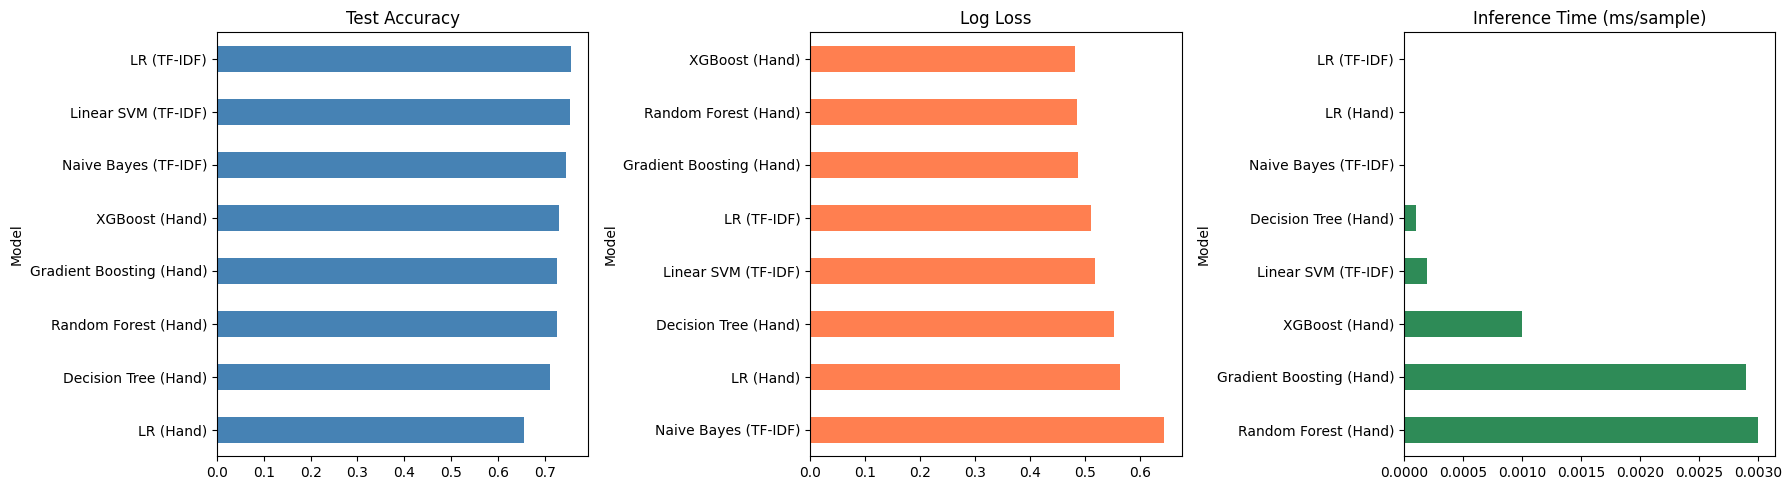

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_df['Test Acc'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Test Accuracy')

results_df['Log Loss'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Log Loss')

results_df['Infer (ms/sample)'].sort_values(ascending=False).plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Inference Time (ms/sample)')

plt.tight_layout()
plt.savefig('outputs/results/traditional_ml_comparison.png', dpi=120)
plt.show()

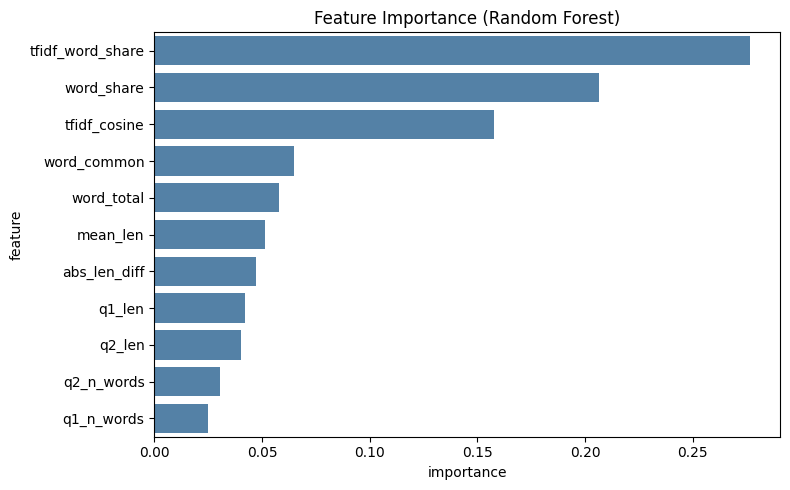

저장 완료: outputs/results/


In [16]:
feat_imp_df = pd.DataFrame({
    'feature': list(X_train_hand.columns),
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_df, x='importance', y='feature', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('outputs/results/feature_importance.png', dpi=120)
plt.show()

print('저장 완료: outputs/results/')